county_health: 2957 rows
access_impact: 2957 rows
priority_counties: 2957 rows
regional_patterns: 49 rows
KIDNEY_DISEASE_PCT            2957
PREVENTABLE_STAYS_AIAN        2681
PREVENTABLE_STAYS_ASIAN       2600
MUAP_DESIGNATED_POPULATION    2291
HISPANIC_WHITE_HOSP_GAP       2221
                              ... 
DISEASE_COUNT                    0
HAS_FQHC                         0
FQHC_SITE_COUNT                  0
FQHC_ORG_COUNT                   0
COUNTY_FIPS                      0
Length: 81, dtype: int64
HISPANIC_WHITE_HOSP_GAP        2221
BLACK_WHITE_HOSP_GAP           1740
HPSA_SCORE                      358
POP_PER_PCP                     156
PCP_PER_100K                    156
LIFE_EXPECTANCY                  84
PREVENTABLE_STAYS_RATE           83
EXCESS_PREVENTABLE_STAYS         83
PREMATURE_AGE_ADJ_MORTALITY      64
HYPERTENSION_PCT                  1
HEART_DISEASE_PCT                 1
COPD_PCT                          1
OBESITY_PCT                       1
DIABETES_PCT    

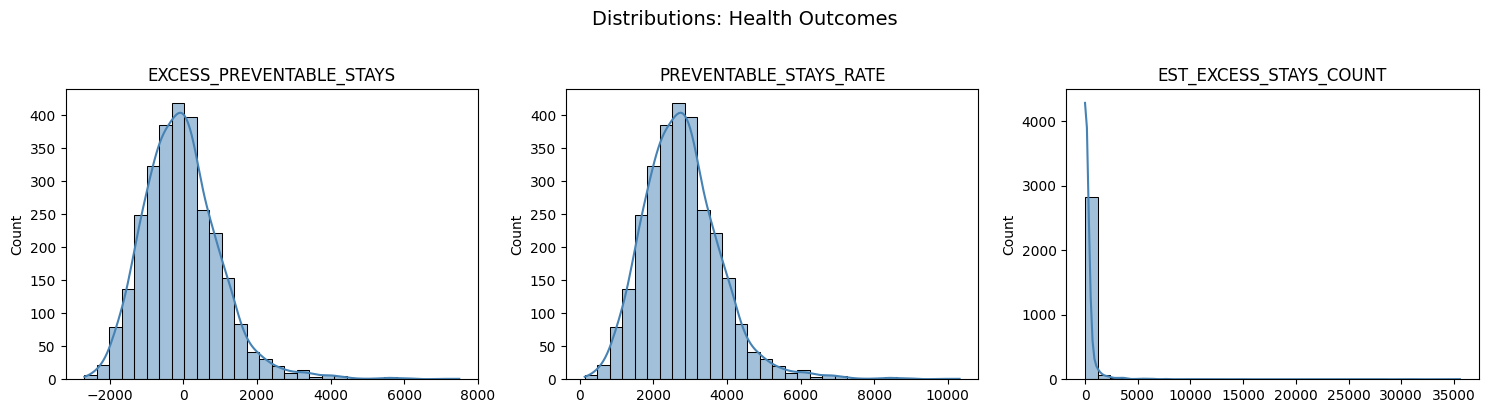

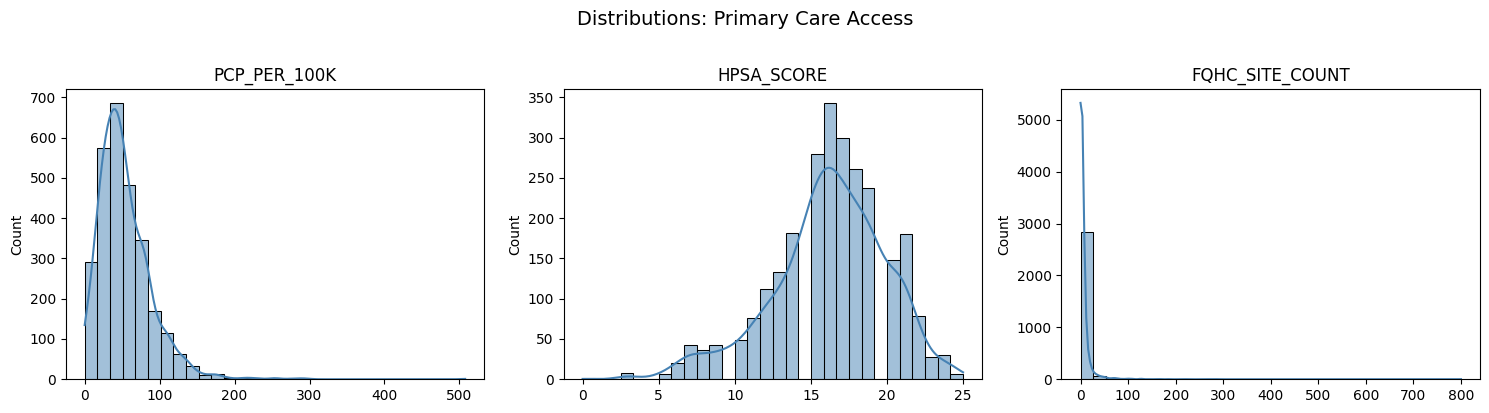

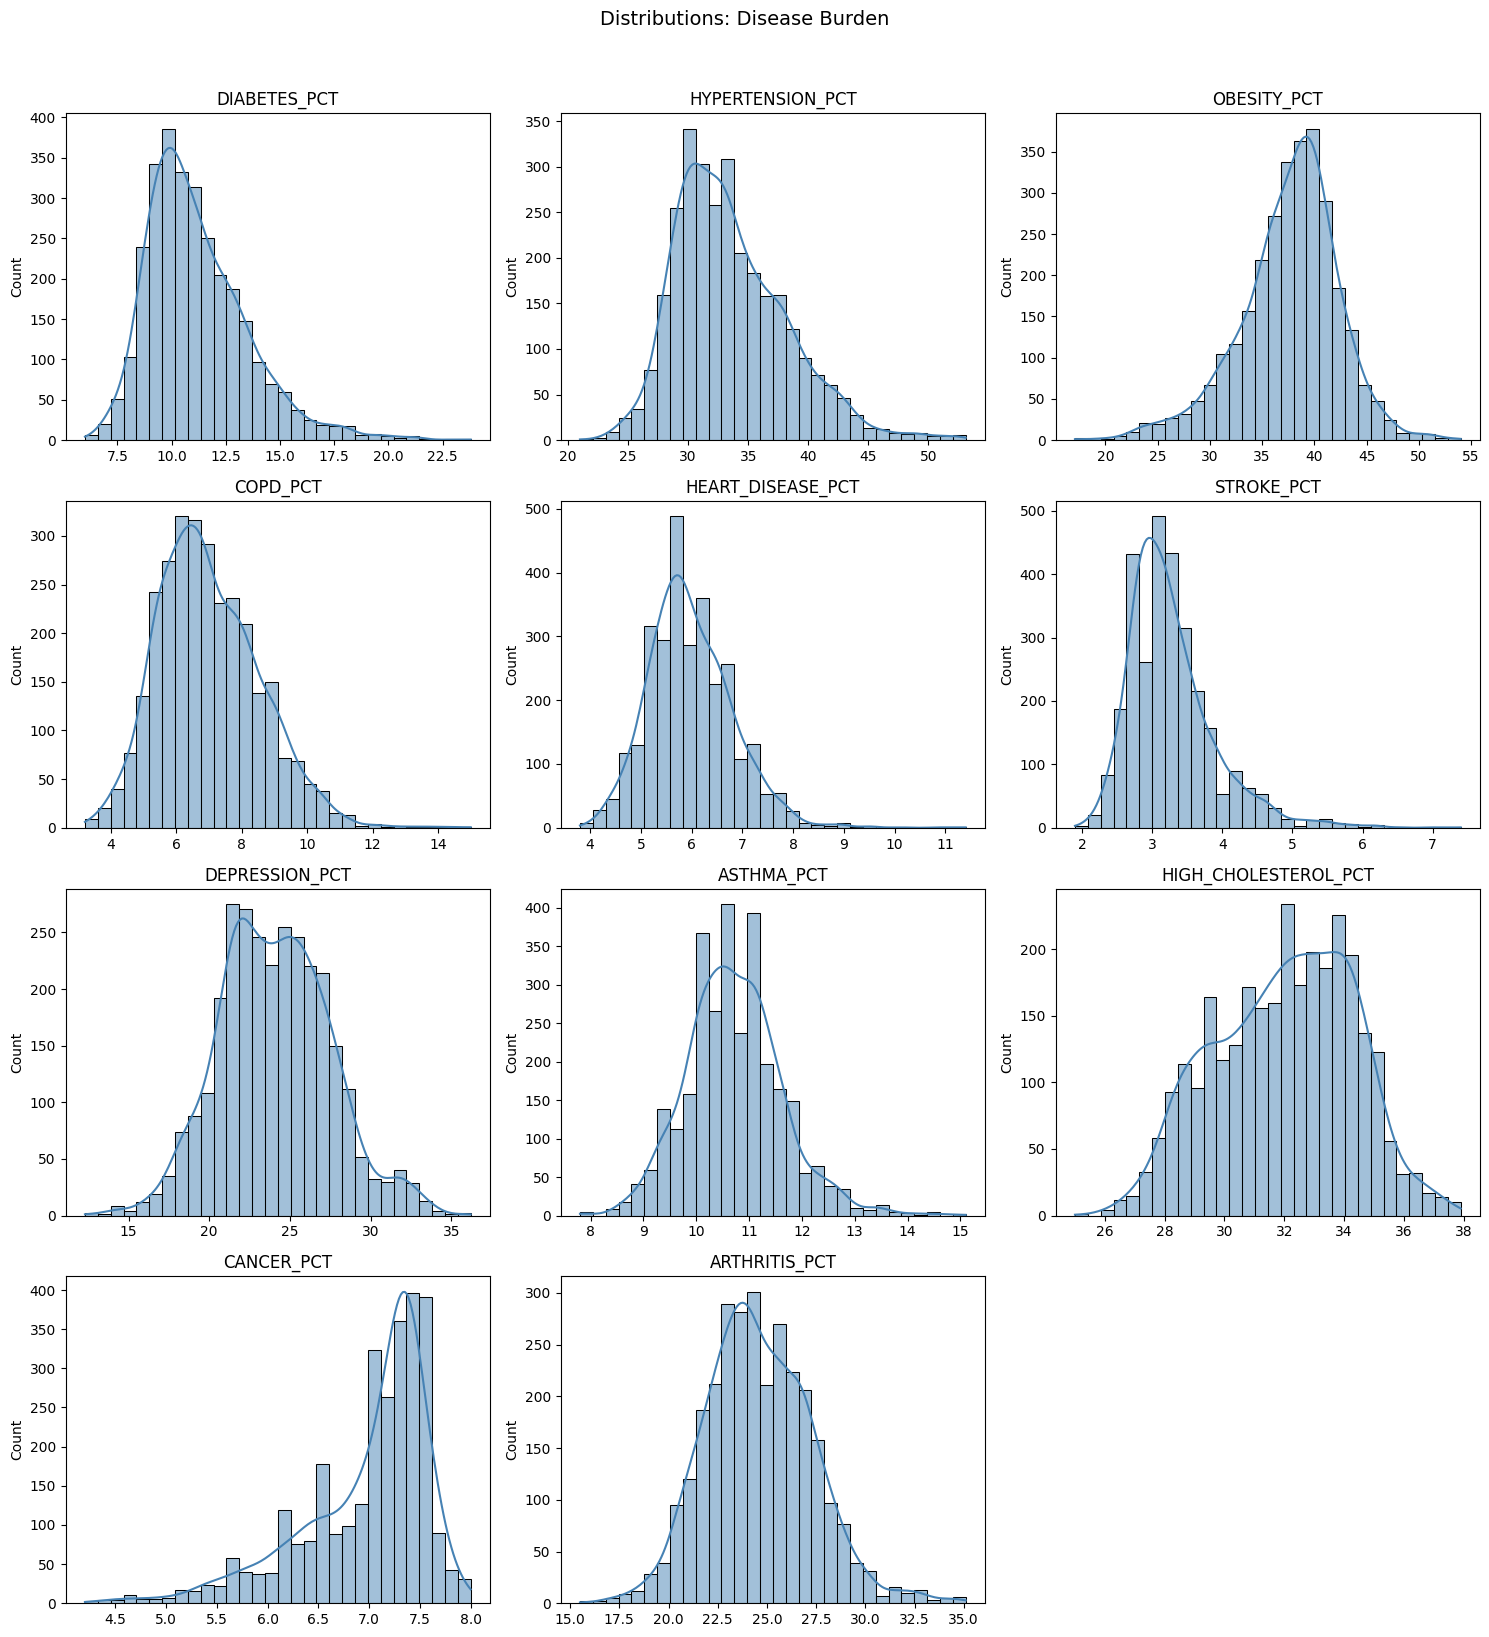

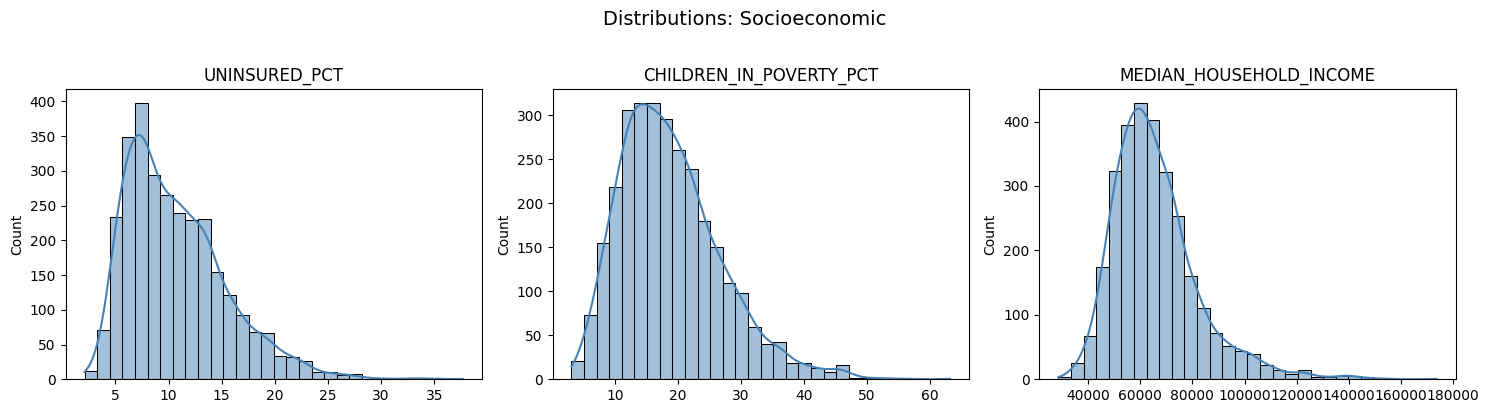


=== BOX PLOTS: HEAVILY SKEWED VARIABLES BY HPSA SEVERITY TIER ===


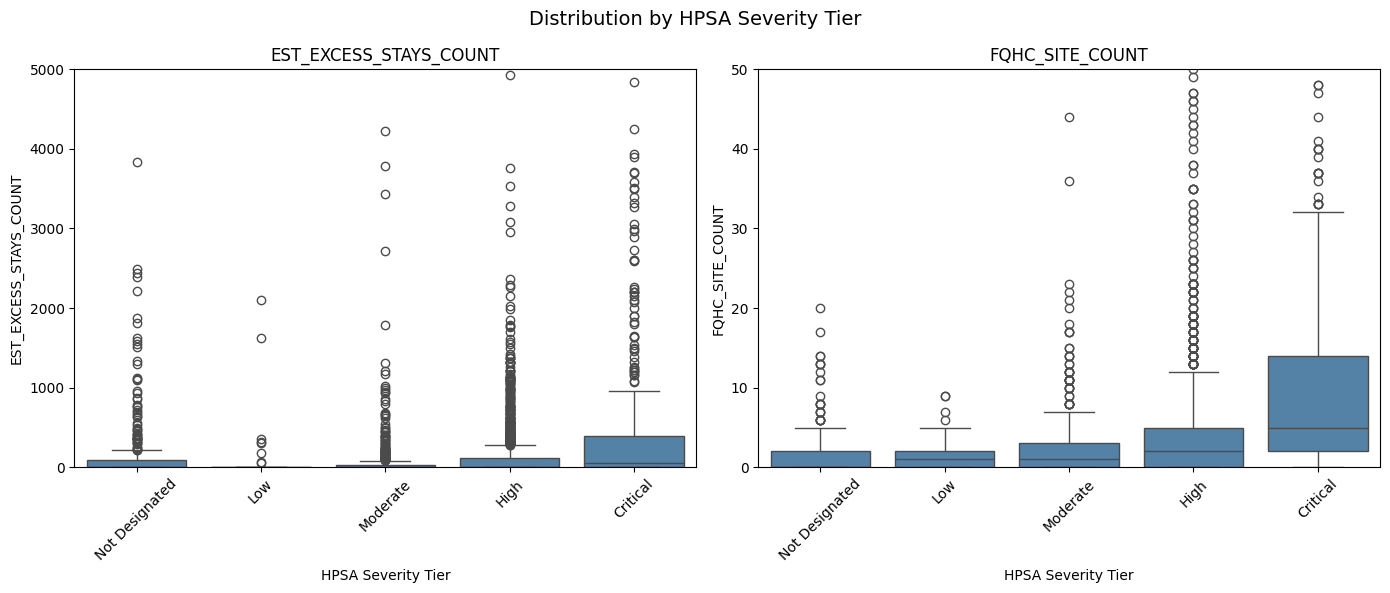


=== CORRELATIONS AND P-VALUES ===

=== HPSA SCORE vs EXCESS PREVENTABLE STAYS ===
r = 0.18, p = 0.0000, n = 2521

=== PCP PER 100K vs EXCESS PREVENTABLE STAYS ===
r = -0.15, p = 0.0000, n = 2737

=== UNINSURED PCT vs EXCESS PREVENTABLE STAYS ===
r = 0.15, p = 0.0000, n = 2874

=== CHILDREN IN POVERTY vs EXCESS PREVENTABLE STAYS ===
r = 0.33, p = 0.0000, n = 2874

=== BLACK WHITE HOSP GAP vs EXCESS PREVENTABLE STAYS ===
r = -0.01, p = 0.6084, n = 1217

=== HISPANIC WHITE HOSP GAP vs EXCESS PREVENTABLE STAYS ===
r = 0.05, p = 0.1695, n = 736

=== IMU SCORE WORST vs EXCESS PREVENTABLE STAYS ===
r = 0.03, p = 0.1113, n = 2258

=== HPSA SCORE vs DIABETES PCT ===
r = 0.39, p = 0.0000, n = 2598

=== HPSA SCORE vs OBESITY PCT ===
r = 0.15, p = 0.0000, n = 2598

=== HPSA SCORE vs HYPERTENSION PCT ===
r = 0.36, p = 0.0000, n = 2598

=== HPSA SCORE vs EXCESS PREVENTABLE STAYS ===
r = 0.18, p = 0.0000, n = 2521

=== PCP PER 100K vs EXCESS PREVENTABLE STAYS ===
r = -0.19, p = 0.0000, n = 2737

===

In [21]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats


# Statistical Analysis: Primary Care Shortage & Health Outcomes

## Supplementary inferential testing to support correlation and group comparison findings
### Dataset: 2,957 US counties | Source: CDC PLACES, HRSA, USDA, County Health Rankings

## 1. Setup & Data Loading

county_health = pd.read_csv("../data-processed/county_health_profile.csv")
access_impact = pd.read_csv("../data-processed/access_impact_analysis.csv")
priority_counties = pd.read_csv("../data-processed/priority_counties_ranking.csv")
regional_patterns = pd.read_csv("../data-processed/regional_patterns.csv")

print("county_health:", len(county_health), "rows")
print("access_impact:", len(access_impact), "rows")
print("priority_counties:", len(priority_counties), "rows")
print("regional_patterns:", len(regional_patterns), "rows")

# Look up missing and negative values

missing_values_county_health = county_health.isnull().sum().sort_values(ascending=False)
print(missing_values_county_health)
missing_values_access_impact = access_impact.isnull().sum().sort_values(ascending=False)
print(missing_values_access_impact)
missing_values_priority_counties = priority_counties.isnull().sum().sort_values(ascending=False)
print(missing_values_priority_counties)
missing_values_regional_patterns = regional_patterns.isnull().sum().sort_values(ascending=False)
print(missing_values_regional_patterns)

print(f"Negative POP_PER_PCP count:{(county_health['POP_PER_PCP'] <= 0).sum()}")

print(county_health[county_health['POP_PER_PCP'] < 0][['COUNTY_NAME', 'STATE_NAME', 'POP_PER_PCP', 'PCP_PER_100K', 'TOTAL_POPULATION']].head(20))

# Only drop NaN for the two columns I'm correlating

subset = county_health[['HPSA_SCORE', 'EXCESS_PREVENTABLE_STAYS']].dropna()

print(len(subset))

## 2. Summary Statistics & Distribution

# Checking distributions of key analytical variables before selecting appropriate 
# statistical tests. Skewness values inform whether parametric or non-parametric 
# tests are appropriate.

# Obtain all columns in county health dataset 

print("county health columns:", county_health.columns.tolist())
print("access impact columns:", access_impact.columns.tolist())
print("priority counties columns:", priority_counties.columns.tolist())
print("regional patterns columns:", regional_patterns.columns.tolist())

# County Health
# Demographics & Socioeconomic
demo_county = ['TOTAL_POPULATION', 'PCT_65_OLDER', 'MEDIAN_HOUSEHOLD_INCOME', 
             'CHILDREN_IN_POVERTY_PCT', 'INCOME_INEQUALITY_RATIO', 
             'UNEMPLOYMENT_PCT', 'UNINSURED_PCT', 'PCT_RURAL']

# Disease Burden
disease_county = ['DIABETES_PCT', 'HYPERTENSION_PCT', 'HEART_DISEASE_PCT', 
                'OBESITY_PCT', 'DEPRESSION_PCT', 'FAIR_POOR_HEALTH_PCT',
                'DISEASE_COUNT']

# Primary Care Access
access_county = ['PCP_PER_100K', 'POP_PER_PCP', 'HPSA_SCORE', 'HPSA_SHORTAGE',
               'HPSA_AVG_PCT_POVERTY', 'IMU_SCORE_AVG', 'FQHC_SITE_COUNT']

# Health Outcomes
outcome_county = ['PREVENTABLE_STAYS_RATE', 'EXCESS_PREVENTABLE_STAYS',
                'LIFE_EXPECTANCY', 'PREMATURE_AGE_ADJ_MORTALITY',
                'INFANT_MORTALITY_RATE', 'EST_EXCESS_STAYS_COUNT',
                'BLACK_WHITE_HOSP_GAP', 'HISPANIC_WHITE_HOSP_GAP']

# Print each group
for name, vars in [('Demographics & Socioeconomic', demo_county),
                   ('Disease Burden', disease_county),
                   ('Primary Care Access', access_county),
                   ('Health Outcomes', outcome_county)]:
    
    print(f"\n=== COUNTY HEALTH | {name} ===")
    print(county_health[vars].describe().round(2))

# Access Impact 
# Demographics & Socioeconomic
demo_impact = ['TOTAL_POPULATION', 'MEDIAN_HOUSEHOLD_INCOME', 
             'CHILDREN_IN_POVERTY_PCT', 'UNINSURED_PCT', 'PCT_RURAL']

# Disease Burden
disease_impact = ['DIABETES_PCT', 'HYPERTENSION_PCT', 'HEART_DISEASE_PCT', 
                'COPD_PCT', 'OBESITY_PCT', 'DISEASE_COUNT', 'DISEASE_BURDEN_LEVEL']

# Primary Care Access
provider_impact = ['PCP_PER_100K', 'POP_PER_PCP', 'HPSA_SCORE', 
               'FQHC_SITE_COUNT', 'IS_HPSA_DESIGNATED', 'IS_MEDICALLY_UNDERSERVED',
               'IS_DUAL_DESIGNATED', 'SHORTAGE_GROUP', 'FQHC_ACCESS_GROUP']

# Health Outcomes
outcome_impact = ['PREVENTABLE_STAYS_RATE', 'EXCESS_PREVENTABLE_STAYS',
                'EST_EXCESS_STAYS_COUNT', 'ABOVE_NATIONAL_AVG_HOSP',
                'LIFE_EXPECTANCY', 'PREMATURE_AGE_ADJ_MORTALITY',
                'BLACK_WHITE_HOSP_GAP', 'HISPANIC_WHITE_HOSP_GAP']

# Print each group
for name, vars in [('Demographics & Socioeconomic', demo_impact),
                   ('Disease Burden', disease_impact),
                   ('Primary Care Access', provider_impact),
                   ('Health Outcomes', outcome_impact)]:
   
    print(f"\n=== ACCESS IMPACT | {name} ===")
    print(access_impact[vars].describe().round(2))

    # Categorical columns
cat_cols = ['DISEASE_BURDEN_LEVEL', 'SHORTAGE_GROUP', 'FQHC_ACCESS_GROUP']
print("\n=== ACCESS IMPACT | Categorical Variables ===")
print(access_impact[cat_cols].describe())

# Priority Counties 
# Demographics & Socioeconomic
demo_priority = ['TOTAL_POPULATION', 'MEDIAN_HOUSEHOLD_INCOME', 
                 'CHILDREN_IN_POVERTY_PCT', 'UNINSURED_PCT', 'PCT_RURAL']

disease_priority = ['DIABETES_PCT', 'HYPERTENSION_PCT', 'HEART_DISEASE_PCT', 
                    'OBESITY_PCT', 'DISEASE_COUNT', 'DISEASE_BURDEN_LEVEL']

provider_priority = ['PCP_PER_100K', 'POP_PER_PCP', 'HPSA_SCORE',
                     'IS_HPSA_DESIGNATED', 'IS_MEDICALLY_UNDERSERVED',
                     'IS_DUAL_DESIGNATED', 'HAS_FQHC', 'VULNERABILITY_SCORE',
                     'PRIORITY_SCORE', 'SHORTAGE_SCORE']

outcome_priority = ['PREVENTABLE_STAYS_RATE', 'EXCESS_PREVENTABLE_STAYS',
                    'ABOVE_NATIONAL_AVG_HOSP', 'LIFE_EXPECTANCY',
                    'BLACK_WHITE_HOSP_GAP', 'HISPANIC_WHITE_HOSP_GAP',
                    'ADMISSIONS_PREVENTABLE', 'DISEASE_SCORE', 'OUTCOME_SCORE']

# Print each group 
for name, vars in [('Demographics & Socioeconomic', demo_priority),
                   ('Disease Burden', disease_priority),
                   ('Primary Care Access', provider_priority),
                   ('Health Outcomes', outcome_priority)]:
    print(f"\n=== PRIORITY COUNTIES | {name} ===")
    print(priority_counties[vars].describe().round(2))

# Rgional Patterns 
demo_regional = ['TOTAL_COUNTIES', 'AVG_UNINSURED_PCT', 'AVG_POVERTY_PCT']

disease_regional = ['HIGH_BURDEN_COUNTIES']

provider_regional = ['HPSA_COUNTIES', 'MUAP_COUNTIES', 'DUAL_DESIGNATED_COUNTIES',
                     'AVG_PCP_PER_100K', 'AVG_PRIORITY_SCORE']

outcome_regional = ['AVG_EXCESS_STAYS']

# Print each group 
for name, vars in [('Demographics & Socioeconomic', demo_regional),
                   ('Disease Burden', disease_regional),
                   ('Primary Care Access', provider_regional),
                   ('Health Outcomes', outcome_regional)]:
    print(f"\n=== REGIONAL PATTERNS | {name} ===")
    print(regional_patterns[vars].describe().round(2))

# Variables with |skew| > 1 are considered highly skewed
# and may require non-parametric tests or log transformation

print("=== Demographics & Socioeconomic Skewness ===")
print(county_health[demo_county].skew(numeric_only=True).sort_values(ascending=False).round(2))

print("\n=== Disease Burden Skewness ===")
print(county_health[disease_county].skew(numeric_only=True).sort_values(ascending=False).round(2))

print("\n=== Primary Care Access Skewness ===")
print(county_health[access_county].skew(numeric_only=True).sort_values(ascending=False).round(2))

print("\n=== Health Outcomes Skewness ===")
print(county_health[outcome_county].skew(numeric_only=True).sort_values(ascending=False).round(2))

print("=== Demographics & Socioeconomic Skewness ===")
print(access_impact[demo_impact].skew(numeric_only=True).sort_values(ascending=False).round(2))

print("\n=== Disease Burden Skewness ===")
print(access_impact[disease_impact].skew(numeric_only=True).sort_values(ascending=False).round(2))

print("\n=== Primary Care Access Skewness ===")
print(access_impact[provider_impact].skew(numeric_only=True).sort_values(ascending=False).round(2))

print("\n=== Health Outcomes Skewness ===")
print(access_impact[outcome_impact].skew(numeric_only=True).sort_values(ascending=False).round(2))

print("=== Demographics & Socioeconomic Skewness ===")
print(priority_counties[demo_priority].skew(numeric_only=True).sort_values(ascending=False).round(2))

print("\n=== Disease Burden Skewness ===")
print(priority_counties[disease_priority].skew(numeric_only=True).sort_values(ascending=False).round(2))

print("\n=== Primary Care Access Skewness ===")
print(priority_counties[provider_priority].skew(numeric_only=True).sort_values(ascending=False).round(2))

print("\n=== Health Outcomes Skewness ===")
print(priority_counties[outcome_priority].skew(numeric_only=True).sort_values(ascending=False).round(2))

print("=== Demographics & Socioeconomic Skewness ===")
print(regional_patterns[demo_regional].skew(numeric_only=True).sort_values(ascending=False).round(2))

print("\n=== Disease Burden Skewness ===")
print(regional_patterns[disease_regional].skew(numeric_only=True).sort_values(ascending=False).round(2))

print("\n=== Primary Care Access Skewness ===")
print(regional_patterns[provider_regional].skew(numeric_only=True).sort_values(ascending=False).round(2))

print("\n=== Health Outcomes Skewness ===")
print(regional_patterns[outcome_regional].skew(numeric_only=True).sort_values(ascending=False).round(2))

## IQR Analysis: HPSA Designated vs Not Designated

iqr_vars = [
    'DIABETES_PCT',
    'HYPERTENSION_PCT',
    'HEART_DISEASE_PCT',
    'COPD_PCT',
    'OBESITY_PCT',
    'DEPRESSION_PCT',
    'STROKE_PCT',
    'ASTHMA_PCT',
    'HIGH_CHOLESTEROL_PCT',
    'CANCER_PCT',
    'ARTHRITIS_PCT'
]

print(f"\n=== IQR ANALYSIS: HPSA DESIGNATED vs NOT DESIGNATED ===")

for var in iqr_vars:
    print(f"\n--- {var} ---")
    print(county_health.groupby('IS_HPSA_DESIGNATED')[var].describe(
        percentiles=[.25, .50, .75]).round(2)[['count', '25%', '50%', '75%', 'mean']])

print(f"\n=== IQR ANALYSIS: BY HPSA SEVERITY TIER ===")

print(county_health['HPSA_SEVERITY_TIER'].value_counts())

tier_order = ['Not Designated', 'Low', 'Moderate', 'High', 'Critical']

for var in iqr_vars:
    print(f"\n--- {var} ---")
    result = county_health.groupby('HPSA_SEVERITY_TIER')[var].describe(
        percentiles=[.25, .50, .75]).round(2)[['count', '25%', '50%', '75%', 'mean']]
    print(result.reindex(tier_order))

print(f"\n=== IQR ANALYSIS: FQHC PRESENCE vs EXCESS PREVENTABLE STAYS ===")

fqhc_vars = ['EXCESS_PREVENTABLE_STAYS', 'EST_EXCESS_STAYS_COUNT']

for var in fqhc_vars:
    print(f"\n--- {var} ---")
    print(county_health.groupby('HAS_FQHC')[var].describe(
        percentiles=[.25, .50, .75]).round(2)[['count', '25%', '50%', '75%', 'mean']])

print(f"\n=== IQR ANALYSIS: BY FQHC ACCESS GROUP ===")

for var in fqhc_vars:
    print(f"\n--- {var} ---")
    print(access_impact.groupby('FQHC_ACCESS_GROUP')[var].describe(
        percentiles=[.25, .50, .75]).round(2)[['count', '25%', '50%', '75%', 'mean']])

dist_vars = {
    'Health Outcomes': [
        'EXCESS_PREVENTABLE_STAYS',
        'PREVENTABLE_STAYS_RATE',
        'EST_EXCESS_STAYS_COUNT'
    ],
    'Primary Care Access': [
        'PCP_PER_100K',
        'HPSA_SCORE',
        'FQHC_SITE_COUNT'
    ],
    'Disease Burden': [
        'DIABETES_PCT',
        'HYPERTENSION_PCT',
        'OBESITY_PCT',
        'COPD_PCT',
        'HEART_DISEASE_PCT',
        'STROKE_PCT',
        'DEPRESSION_PCT',
        'ASTHMA_PCT',
        'HIGH_CHOLESTEROL_PCT',
        'CANCER_PCT',
        'ARTHRITIS_PCT'
    ],
    'Socioeconomic': [
        'UNINSURED_PCT',
        'CHILDREN_IN_POVERTY_PCT',
        'MEDIAN_HOUSEHOLD_INCOME'
    ]
}

print(f"\n=== HISTOGRAMS CONTINUOUS VARIABLES ===")

for group_name, vars in dist_vars.items():
    n_vars = len(vars)
    n_cols = 3
    n_rows = (n_vars + n_cols - 1) // n_cols  # ceiling division
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
    fig.suptitle(f'Distributions: {group_name}', fontsize=14, y=1.02)
    axes = axes.flatten()
    
    for i, var in enumerate(vars):
        sns.histplot(
            data=county_health[var].dropna(),
            ax=axes[i],
            bins=30,
            kde=True,          # adds smoothed density curve
            color='steelblue'
        )
        axes[i].set_title(var)
        axes[i].set_xlabel('')
    
    # hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()

print(f"\n=== BOX PLOTS: HEAVILY SKEWED VARIABLES BY HPSA SEVERITY TIER ===")

boxplot_vars = ['EST_EXCESS_STAYS_COUNT', 'FQHC_SITE_COUNT']

tier_order = ['Not Designated', 'Low', 'Moderate', 'High', 'Critical']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Distribution by HPSA Severity Tier', fontsize=14)

for i, var in enumerate(boxplot_vars):
    sns.boxplot(
        data=county_health,
        x='HPSA_SEVERITY_TIER',
        y=var,
        order=tier_order,
        ax=axes[i],
        color='steelblue'
    )
    axes[i].set_title(var)
    axes[i].set_xlabel('HPSA Severity Tier')
    axes[i].tick_params(axis='x', rotation=45)

axes[0].set_ylim(0, 5000)   # EST_EXCESS_STAYS_COUNT
axes[1].set_ylim(0, 50)     # FQHC_SITE_COUNT

plt.tight_layout()
plt.show()

## 3. P-values for Correlations

# Testing statistical significance of Pearson correlations reported in the main 
# analysis.

# Define all correlation pairs from your SQL analyses

print(f"\n=== CORRELATIONS AND P-VALUES ===")

# Statistical Significance of Correlations

## 3. Statistical Significance of Pearson Correlations

# HPSA_SCORE vs EXCESS_PREVENTABLE_STAYS
print("\n=== HPSA SCORE vs EXCESS PREVENTABLE STAYS ===")
subset = county_health[['HPSA_SCORE', 'EXCESS_PREVENTABLE_STAYS']].dropna()
r, p = stats.pearsonr(subset['HPSA_SCORE'], subset['EXCESS_PREVENTABLE_STAYS'])
print(f"r = {r:.2f}, p = {p:.4f}, n = {len(subset)}")

# PCP_PER_100K vs EXCESS_PREVENTABLE_STAYS
print("\n=== PCP PER 100K vs EXCESS PREVENTABLE STAYS ===")
subset = county_health[['PCP_PER_100K', 'EXCESS_PREVENTABLE_STAYS']].dropna()
r, p = stats.pearsonr(subset['PCP_PER_100K'], subset['EXCESS_PREVENTABLE_STAYS'])
print(f"r = {r:.2f}, p = {p:.4f}, n = {len(subset)}")

# UNINSURED_PCT vs EXCESS_PREVENTABLE_STAYS
print("\n=== UNINSURED PCT vs EXCESS PREVENTABLE STAYS ===")
subset = county_health[['UNINSURED_PCT', 'EXCESS_PREVENTABLE_STAYS']].dropna()
r, p = stats.pearsonr(subset['UNINSURED_PCT'], subset['EXCESS_PREVENTABLE_STAYS'])
print(f"r = {r:.2f}, p = {p:.4f}, n = {len(subset)}")

# CHILDREN_IN_POVERTY_PCT vs EXCESS_PREVENTABLE_STAYS
print("\n=== CHILDREN IN POVERTY vs EXCESS PREVENTABLE STAYS ===")
subset = county_health[['CHILDREN_IN_POVERTY_PCT', 'EXCESS_PREVENTABLE_STAYS']].dropna()
r, p = stats.pearsonr(subset['CHILDREN_IN_POVERTY_PCT'], subset['EXCESS_PREVENTABLE_STAYS'])
print(f"r = {r:.2f}, p = {p:.4f}, n = {len(subset)}")

# BLACK_WHITE_HOSP_GAP vs EXCESS_PREVENTABLE_STAYS
print("\n=== BLACK WHITE HOSP GAP vs EXCESS PREVENTABLE STAYS ===")
subset = county_health[['BLACK_WHITE_HOSP_GAP', 'EXCESS_PREVENTABLE_STAYS']].dropna()
r, p = stats.pearsonr(subset['BLACK_WHITE_HOSP_GAP'], subset['EXCESS_PREVENTABLE_STAYS'])
print(f"r = {r:.2f}, p = {p:.4f}, n = {len(subset)}")

# HISPANIC_WHITE_HOSP_GAP vs EXCESS_PREVENTABLE_STAYS
print("\n=== HISPANIC WHITE HOSP GAP vs EXCESS PREVENTABLE STAYS ===")
subset = county_health[['HISPANIC_WHITE_HOSP_GAP', 'EXCESS_PREVENTABLE_STAYS']].dropna()
r, p = stats.pearsonr(subset['HISPANIC_WHITE_HOSP_GAP'], subset['EXCESS_PREVENTABLE_STAYS'])
print(f"r = {r:.2f}, p = {p:.4f}, n = {len(subset)}")

# IMU_SCORE_WORST vs EXCESS_PREVENTABLE_STAYS
print("\n=== IMU SCORE WORST vs EXCESS PREVENTABLE STAYS ===")
subset = county_health[['IMU_SCORE_WORST', 'EXCESS_PREVENTABLE_STAYS']].dropna()
r, p = stats.pearsonr(subset['IMU_SCORE_WORST'], subset['EXCESS_PREVENTABLE_STAYS'])
print(f"r = {r:.2f}, p = {p:.4f}, n = {len(subset)}")

# HPSA_SCORE vs DIABETES_PCT
print("\n=== HPSA SCORE vs DIABETES PCT ===")
subset = county_health[['HPSA_SCORE', 'DIABETES_PCT']].dropna()
r, p = stats.pearsonr(subset['HPSA_SCORE'], subset['DIABETES_PCT'])
print(f"r = {r:.2f}, p = {p:.4f}, n = {len(subset)}")

# HPSA_SCORE vs OBESITY_PCT
print("\n=== HPSA SCORE vs OBESITY PCT ===")
subset = county_health[['HPSA_SCORE', 'OBESITY_PCT']].dropna()
r, p = stats.pearsonr(subset['HPSA_SCORE'], subset['OBESITY_PCT'])
print(f"r = {r:.2f}, p = {p:.4f}, n = {len(subset)}")

# HPSA_SCORE vs HYPERTENSION_PCT
print("\n=== HPSA SCORE vs HYPERTENSION PCT ===")
subset = county_health[['HPSA_SCORE', 'HYPERTENSION_PCT']].dropna()
r, p = stats.pearsonr(subset['HPSA_SCORE'], subset['HYPERTENSION_PCT'])
print(f"r = {r:.2f}, p = {p:.4f}, n = {len(subset)}")

# Statistical Significance of Spearman Correlations

# HPSA_SCORE vs EXCESS_PREVENTABLE_STAYS
print("\n=== HPSA SCORE vs EXCESS PREVENTABLE STAYS ===")
subset = county_health[['HPSA_SCORE', 'EXCESS_PREVENTABLE_STAYS']].dropna()
r, p = stats.spearmanr(subset['HPSA_SCORE'], subset['EXCESS_PREVENTABLE_STAYS'])
print(f"r = {r:.2f}, p = {p:.4f}, n = {len(subset)}")

# PCP_PER_100K vs EXCESS_PREVENTABLE_STAYS
print("\n=== PCP PER 100K vs EXCESS PREVENTABLE STAYS ===")
subset = county_health[['PCP_PER_100K', 'EXCESS_PREVENTABLE_STAYS']].dropna()
r, p = stats.spearmanr(subset['PCP_PER_100K'], subset['EXCESS_PREVENTABLE_STAYS'])
print(f"r = {r:.2f}, p = {p:.4f}, n = {len(subset)}")

# UNINSURED_PCT vs EXCESS_PREVENTABLE_STAYS
print("\n=== UNINSURED PCT vs EXCESS PREVENTABLE STAYS ===")
subset = county_health[['UNINSURED_PCT', 'EXCESS_PREVENTABLE_STAYS']].dropna()
r, p = stats.spearmanr(subset['UNINSURED_PCT'], subset['EXCESS_PREVENTABLE_STAYS'])
print(f"r = {r:.2f}, p = {p:.4f}, n = {len(subset)}") 

# CHILDREN_IN_POVERTY_PCT vs EXCESS_PREVENTABLE_STAYS
print("\n=== CHILDREN IN POVERTY vs EXCESS PREVENTABLE STAYS ===")
subset = county_health[['CHILDREN_IN_POVERTY_PCT', 'EXCESS_PREVENTABLE_STAYS']].dropna()
r, p = stats.spearmanr(subset['CHILDREN_IN_POVERTY_PCT'], subset['EXCESS_PREVENTABLE_STAYS'])
print(f"r = {r:.2f}, p = {p:.4f}, n = {len(subset)}")

# BLACK_WHITE_HOSP_GAP vs EXCESS_PREVENTABLE_STAYS
print("\n=== BLACK WHITE HOSP GAP vs EXCESS PREVENTABLE STAYS ===")
subset = county_health[['BLACK_WHITE_HOSP_GAP', 'EXCESS_PREVENTABLE_STAYS']].dropna()
r, p = stats.spearmanr(subset['BLACK_WHITE_HOSP_GAP'], subset['EXCESS_PREVENTABLE_STAYS'])
print(f"r = {r:.2f}, p = {p:.4f}, n = {len(subset)}")

# HISPANIC_WHITE_HOSP_GAP vs EXCESS_PREVENTABLE_STAYS
print("\n=== HISPANIC WHITE HOSP GAP vs EXCESS PREVENTABLE STAYS ===")
subset = county_health[['HISPANIC_WHITE_HOSP_GAP', 'EXCESS_PREVENTABLE_STAYS']].dropna()
r, p = stats.spearmanr(subset['HISPANIC_WHITE_HOSP_GAP'], subset['EXCESS_PREVENTABLE_STAYS'])
print(f"r = {r:.2f}, p = {p:.4f}, n = {len(subset)}")

# IMU_SCORE_WORST vs EXCESS_PREVENTABLE_STAYS
print("\n=== IMU SCORE WORST vs EXCESS PREVENTABLE STAYS ===")
subset = county_health[['IMU_SCORE_WORST', 'EXCESS_PREVENTABLE_STAYS']].dropna()
r, p = stats.spearmanr(subset['IMU_SCORE_WORST'], subset['EXCESS_PREVENTABLE_STAYS'])
print(f"r = {r:.2f}, p = {p:.4f}, n = {len(subset)}")

# HPSA_SCORE vs DIABETES_PCT
print("\n=== HPSA SCORE vs DIABETES PCT ===")
subset = county_health[['HPSA_SCORE', 'DIABETES_PCT']].dropna()
r, p = stats.spearmanr(subset['HPSA_SCORE'], subset['DIABETES_PCT'])
print(f"r = {r:.2f}, p = {p:.4f}, n = {len(subset)}")

# HPSA_SCORE vs HYPERTENSION_PCT
print("\n=== HPSA SCORE vs HYPERTENSION PCT ===")
subset = county_health[['HPSA_SCORE', 'HYPERTENSION_PCT']].dropna()
r, p = stats.spearmanr(subset['HPSA_SCORE'], subset['HYPERTENSION_PCT'])
print(f"r = {r:.2f}, p = {p:.4f}, n = {len(subset)}")

# HPSA_SCORE vs OBESITY_PCT
print("\n=== HPSA SCORE vs OBESITY PCT ===")
subset = county_health[['HPSA_SCORE', 'OBESITY_PCT']].dropna()
r, p = stats.spearmanr(subset['HPSA_SCORE'], subset['OBESITY_PCT'])
print(f"r = {r:.2f}, p = {p:.4f}, n = {len(subset)}")

## 4. T-tests for Group Comparisons

# Formally testing whether differences in chronic disease prevalence between 
# HPSA-designated and non-designated counties are statistically significant.
# Test choice (parametric vs non-parametric) informed by distribution analysis above.

## 5. Chi-squared Test

# Testing association between HPSA designation and above-average preventable 
# hospitalization rates using a contingency table approach.

## 6. Summary of Findings